In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import random
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from pathlib import Path

In [2]:
!pip install -q kaggle
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors




  0%|          | 0.00/778M [00:00<?, ?B/s]
  0%|          | 1.00M/778M [00:00<11:45, 1.15MB/s]
  0%|          | 2.00M/778M [00:01<09:31, 1.42MB/s]
  0%|          | 3.00M/778M [00:02<08:48, 1.54MB/s]
  1%|          | 4.00M/778M [00:03<10:00, 1.35MB/s]
  1%|          | 5.00M/778M [00:03<09:17, 1.45MB/s]
  1%|          | 6.00M/778M [00:04<08:49, 1.53MB/s]
  1%|          | 7.00M/778M [00:04<08:31, 1.58MB/s]
  1%|          | 8.00M/778M [00:05<08:55, 1.51MB/s]
  1%|          | 9.00M/778M [00:06<08:35, 1.57MB/s]
  1%|▏         | 10.0M/778M [00:06<08:39, 1.55MB/s]
  1%|▏         | 11.0M/778M [00:07<08:28, 1.58MB/s]
  2%|▏         | 12.0M/778M [00:08<08:14, 1.62MB/s]
  2%|▏         | 13.0M/778M [00:08<08:05, 1.65MB/s]
  2%|▏         | 14.0M/778M [00:09<08:02, 1.66MB/s]
  2%|▏         | 15.0M/778M [00:10<07:57, 1.68MB/s]
  2%|▏         | 16.0M/778M [00:10<08:00, 1.66MB/s]
  2%|▏         | 17.0M/778M [00:11<07:56, 1.67MB/s]
  2%|▏         | 18.0M/778M [00:11<07:54, 1.68MB/s]
  2%|▏         | 19.

In [3]:
with zipfile.ZipFile('covid19-radiography-database.zip') as z:
    z.extractall('chest_xray_dataset')

In [4]:
PATH = 'chest_xray_dataset/COVID-19_Radiography_Dataset'

raw_cat = [d for d in os.listdir(PATH) if os.path.isdir(os.path.join(PATH, d))]
print(f"Catogires is: {raw_cat}")

Catogires is: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


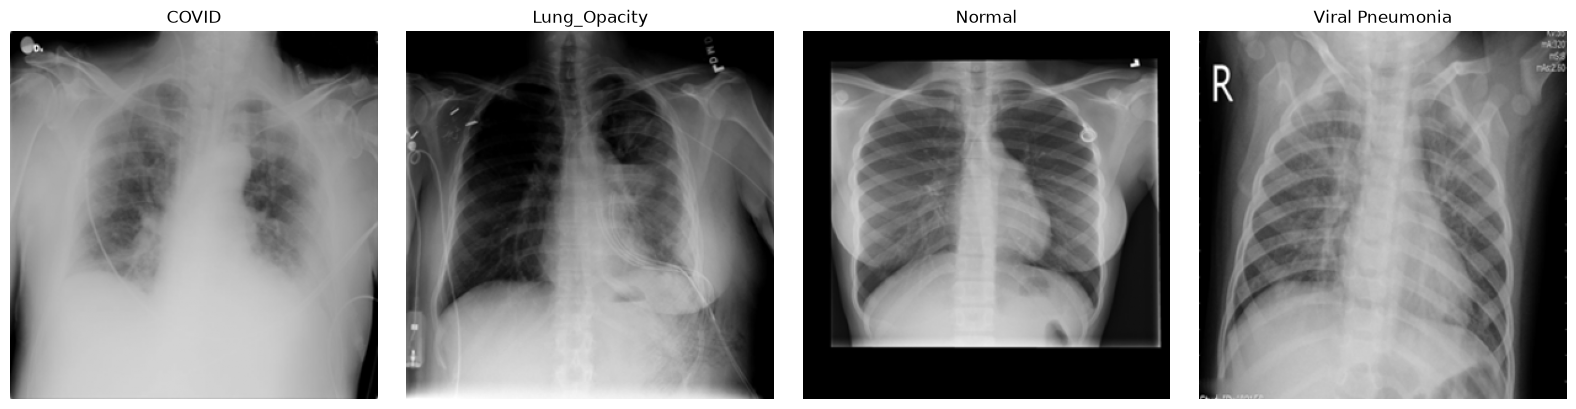

In [7]:
path = Path('chest_xray_dataset/COVID-19_Radiography_Dataset')
categories = [d.name for d in path.iterdir() if d.is_dir()]

plt.figure(figsize=(len(categories) * 4, 4))

for i, category in enumerate(categories):
    cat_dir = path / category
    img_path = next((p for p in cat_dir.rglob('*.png') if 'mask' not in str(p).lower()), None)

    if img_path:
        img = Image.open(img_path)

        plt.subplot(1, len(categories), i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

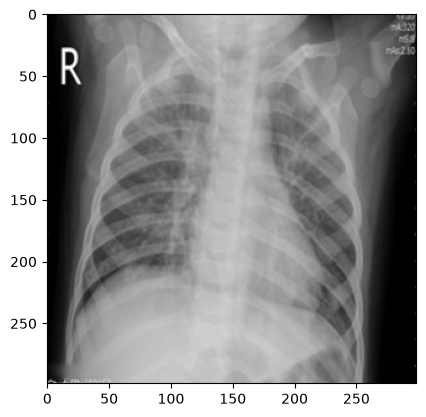

In [17]:
plt.imshow(img, cmap='gray')

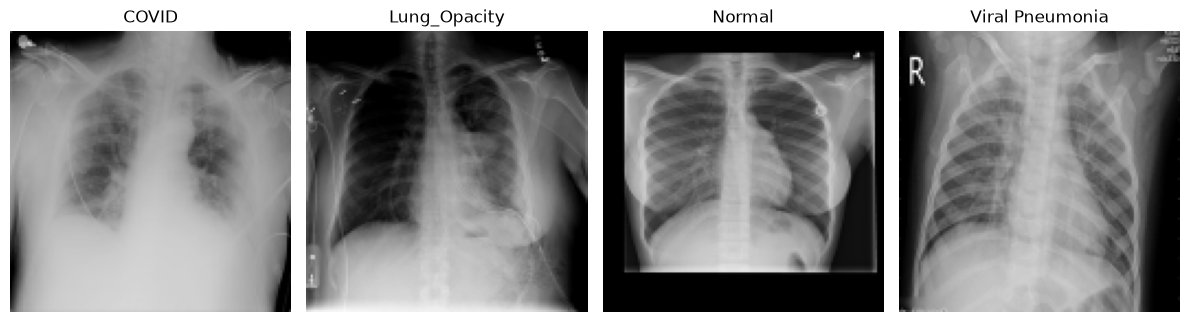

In [24]:
plt.figure(figsize=(12, 4))

for i, category in enumerate(categories):
    img_path = next((path / category).rglob('*.png'), None)
    if img_path:
        img = cv2.resize(cv2.imread(str(img_path)), (128, 128))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(categories), i + 1)
        plt.imshow(img_rgb)
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
model = Sequential()

# Layer 1
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(299, 299, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 2
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 3
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 4
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(GlobalAveragePooling2D())

# Fully Connected layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

C:\Users\Ahmed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
filepaths = []
labels = []

for cat_dir in [d for d in path.iterdir() if d.is_dir()]:
    images_dir = cat_dir / 'images'
    search_dir = images_dir if images_dir.exists() else cat_dir
    for img_path in search_dir.rglob('*.[pP][nN][gG]'):
        filepaths.append(str(img_path.resolve()))
        labels.append(cat_dir.name)

df = pd.DataFrame({'filename': filepaths, 'class': labels})

train_df, val_test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['class']
)
valid_df, test_df = train_test_split(
    val_test_df, test_size=0.5, random_state=42, stratify=val_test_df['class']
)

generator_train = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.08,
    height_shift_range=0.08,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

generator_test = ImageDataGenerator(
    rescale=1./255
)

train = generator_train.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

val = generator_test.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filename',
    y_col='class',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

test = generator_test.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 16932 validated image filenames belonging to 4 classes.
Found 2116 validated image filenames belonging to 4 classes.
Found 2117 validated image filenames belonging to 4 classes.


In [27]:
model1_es = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=8,
    verbose=1,
    restore_best_weights=True
)

model1_rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

model1_mcp = ModelCheckpoint(
    filepath='model_1_CNN.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:


model1_es = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=8,
    verbose=1,
    restore_best_weights=True
)

model1_rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model1_mcp = ModelCheckpoint(
    filepath=drive_model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train,
    epochs=20,
    validation_data=val,
    callbacks=[model1_es, model1_rlr, model1_mcp]
)

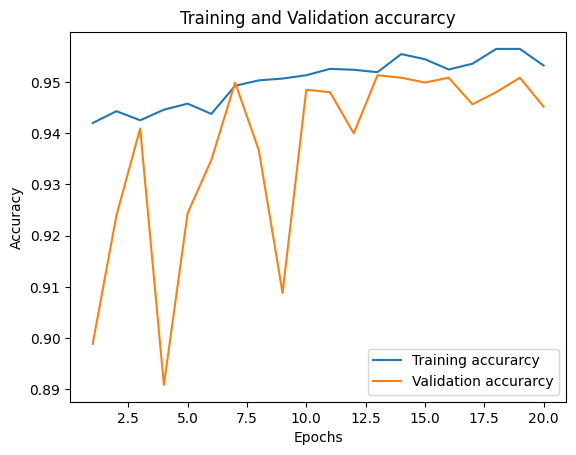

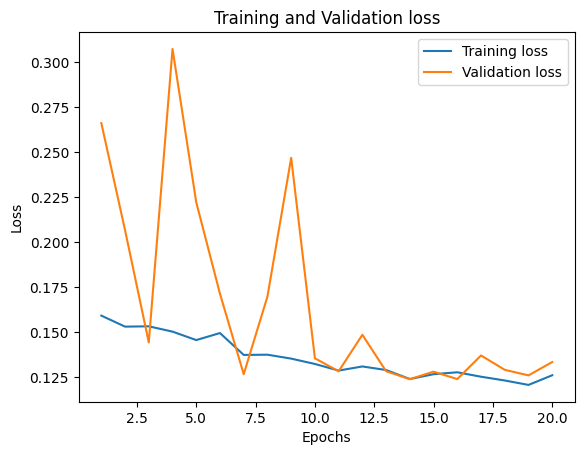

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, label='Training accurarcy')
plt.plot(epochs, val_acc, label='Validation accurarcy')
plt.title('Training and Validation accurarcy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss,  label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
 model = keras.models.load_model('model_1_CNN.keras')

In [ ]:
model.evaluate(test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.9169 - loss: 0.2402 - precision: 0.9198 - recall: 0.9159


[0.24017105996608734, 0.9168635010719299, 0.919829249382019, 0.91591876745224]

67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step
Accuracy is:  0.9555975436939065


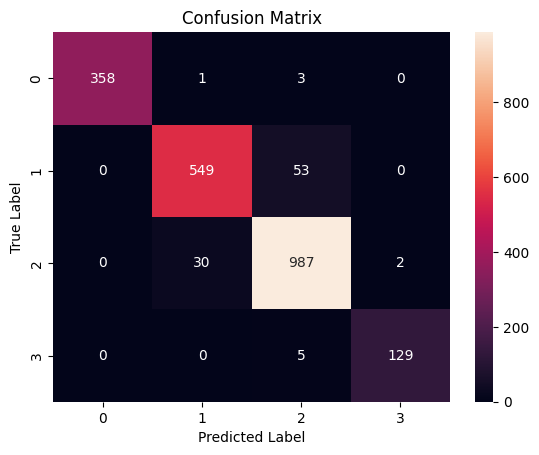

In [15]:

y_pred_test = model.predict(test, verbose=1)
y_pred_test_int = y_pred_test.argmax(axis=1)

y_true_test_int = test.classes

ac = accuracy_score(y_true_test_int, y_pred_test_int)
print('Accuracy is: ',ac)
cm = confusion_matrix(y_true_test_int, y_pred_test_int)
sn.heatmap(cm,annot=True,fmt="d")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [19]:
target_names = ['COVID', 'Lung_Opacity', 'NORMAL', 'Viral Pneumonia']
print(classification_report(y_true_test_int, y_pred_test_int, target_names=target_names, digits=4))

                 precision    recall  f1-score   support

          COVID     1.0000    0.9890    0.9944       362
   Lung_Opacity     0.9466    0.9120    0.9289       602
         NORMAL     0.9418    0.9686    0.9550      1019
Viral Pneumonia     0.9847    0.9627    0.9736       134

       accuracy                         0.9556      2117
      macro avg     0.9683    0.9580    0.9630      2117
   weighted avg     0.9558    0.9556    0.9555      2117



In [23]:
print(train.class_indices)

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [ ]:
model.save('model_1_CNN.keras')